To do:

- working with events
- creating epochs
- baselining
- averaging epochs and plotting evoked responses
- re-referencing (could cover this in the "evoked" section)
- removing bad data (channels, epochs, autoreject)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mne

sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(sample_data_raw_file, preload=True)
raw.pick(picks=["eeg", "stim"]);
raw.filter(0.2, 50)

Opening raw data file /home/olebi/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.2 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.20
- Lower transition bandwidth: 0.20 Hz (-6 dB cutoff frequency: 0.10 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 9911 samples (16.501 s)



<Raw | sample_audvis_raw.fif, 69 x 166800 (277.7 s), ~90.8 MiB, data loaded>

## Working with Event Data

| Code | Description |
| --- | --- |
| `events = mne.find_events(raw)` | Read the `events` from the stimulus channel of `raw` |
| `events[:3]` | Access the first three rows of the `events` table |
| `mne.viz.plot(events)` | Plot the `events` |
| `mne.viz.plot(events, first_samp=1000)` | Plot the `events` starting at sample `1000` |
| `mne.merge_events(events, ids=[1,2], new_id=3)` | Merge the `events` with the code `1` and `2` and assign the code `3` to the merged event |

Run the cell below two plot one EEG channel along with the stimulus channel

Using matplotlib as 2D backend.


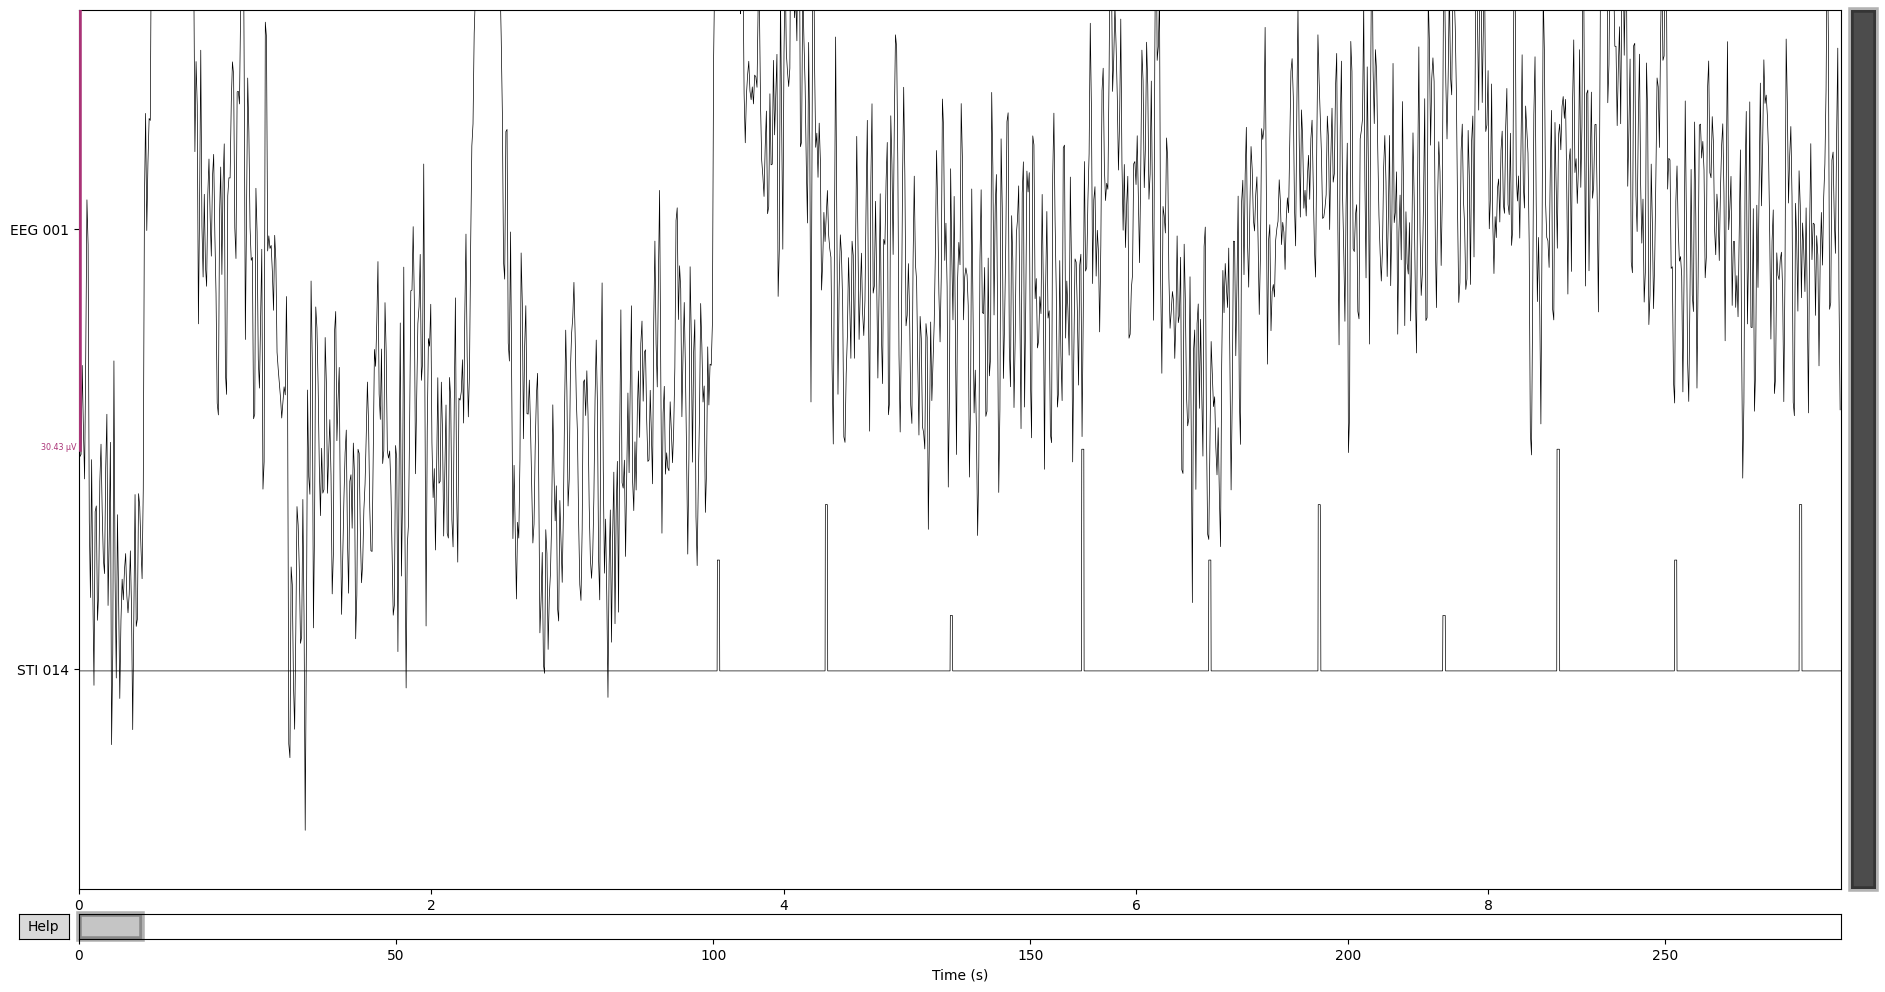

In [2]:
raw.plot(picks=["EEG 001", "STI 014"], scalings="auto");

Use `mne.find_events()` to read the events from the stimulus channel of `raw` and print the first 10 `events`. The first column is the sample where the event occurred, the last column is the event code.

In [3]:
events = events = mne.find_events(raw, stim_channel="STI 014")
events[:10]

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]


array([[27977,     0,     2],
       [28345,     0,     3],
       [28771,     0,     1],
       [29219,     0,     4],
       [29652,     0,     2],
       [30025,     0,     3],
       [30450,     0,     1],
       [30839,     0,     4],
       [31240,     0,     2],
       [31665,     0,     3]])

**Exercise**: `plot_events()` to plot the first 100 entries of `events` (TIP: set `first_samp=25000` because the first part of the recording does not contain any events).

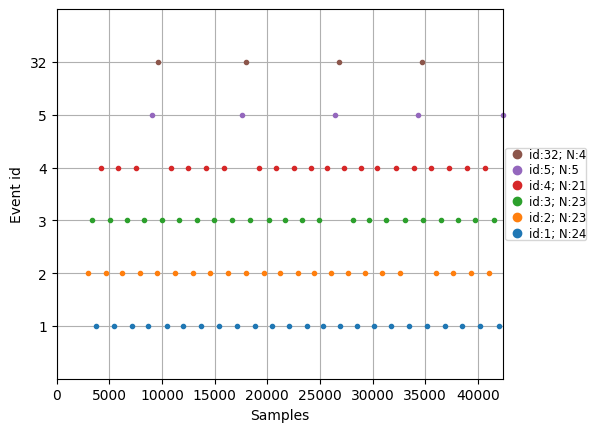

In [4]:
mne.viz.plot_events(events[:100], first_samp=25000);

The events are encoded as integer numbers but we can attach labels to them to describe actual event that is represented by this number. The dictionary `event_id` contains descriptions of the different events in our data.

In [5]:
event_id = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
    "face": 5,
    "button": 32,
}

**Exercise**: Plot the first 100 entries in `events` again but set `event_id=event_id` to display the event description in the legend.

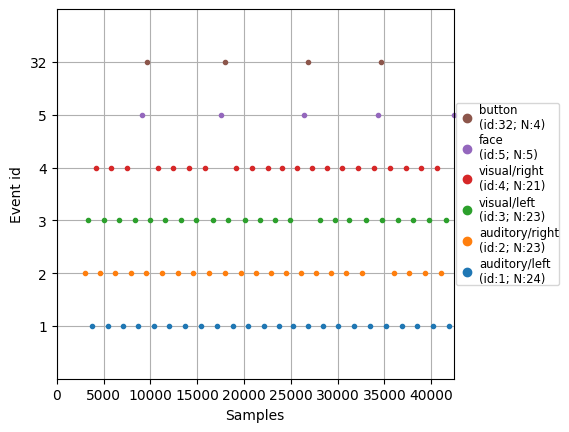

In [6]:
mne.viz.plot_events(events[:100], first_samp=25000, event_id=event_id);

**Example**: Merge the events `3` and `4` (i.e. the left and right visual stimulus), encode the merged event with the number `34` and overwrite the existing `events`.

In [7]:
events = mne.merge_events(events, ids=[3,4], new_id=34)

**Exercise**: Merge the events `1` and `2` (i.e. the left and right auditory stimulus) and encode the merged event with the number `12` and overwrite the existing event.

In [8]:
events = mne.merge_events(events, ids=[1,2], new_id=12)

**Exercise**: create a new dictionary `event_id` with the new merged event codes `"auditory: 12"` and `"visual:34"`.

In [9]:
event_id = {
    "auditory": 12,
    "visual": 34,
    "face": 5,
    "button": 32,
}

**Exercise**: Plot the first 50 entries in `events` with the new `event_id`.

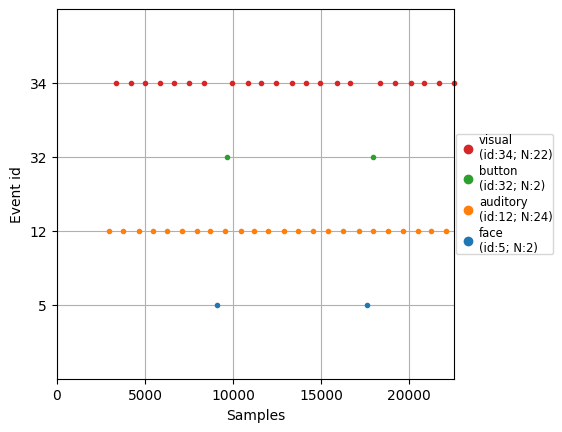

In [10]:
mne.viz.plot_events(events[:50], first_samp=25000, event_id=event_id);

## Epoching and Averaging Continuous EEG Data

| Code | Data |
| --- | --- |
| `epochs = mne.epochs.Epochs(raw, events, tmin=-0.3, tmax=1)` | Divide the `raw` data into epochs from `-0.3` to `1` seconds relative to the `events` |
| `epochs = mne.epochs.Epochs(raw, events, tmin=-0.3, tmax=1, event_id=event_id)` | Divide the `raw` data into epochs and add an `event_id` |
| `epochs = mne.epochs.Epochs(raw, events, tmin=-0.3, tmax=1, baseline=(-0.1, 0))` | Divide the `raw` data into epochs and use the time interval from `-0.1` to `0` seconds as `baseline` |
| `epochs = mne.epochs.Epochs(raw, events, tmin=-0.3, tmax=1, baseline=None)` | Apply no `baseline` (per default the window before the event (i.e. time 0) is used as baseline)|
| `epochs.plot()` | Plot the epoched data |
| `epochs.average().plot()` | Plot the average of all `epochs` |
| `epochs["stim1"].average().plot()` | Plot the average of all `epochs` for the event ID `"stim1"` |

**Example**: We can use the events to cut the `raw` data into equally long segments around the `events`. These segments are called `epochs`. Run the cell to create `epochs` starting `0.3` seconds before and ending `1` second after each event. Then plot the epoched data.

Not setting metadata
320 matching events found
Setting baseline interval to [-0.2996928197375818, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 320 events and 782 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 20 events and 782 original time points ...


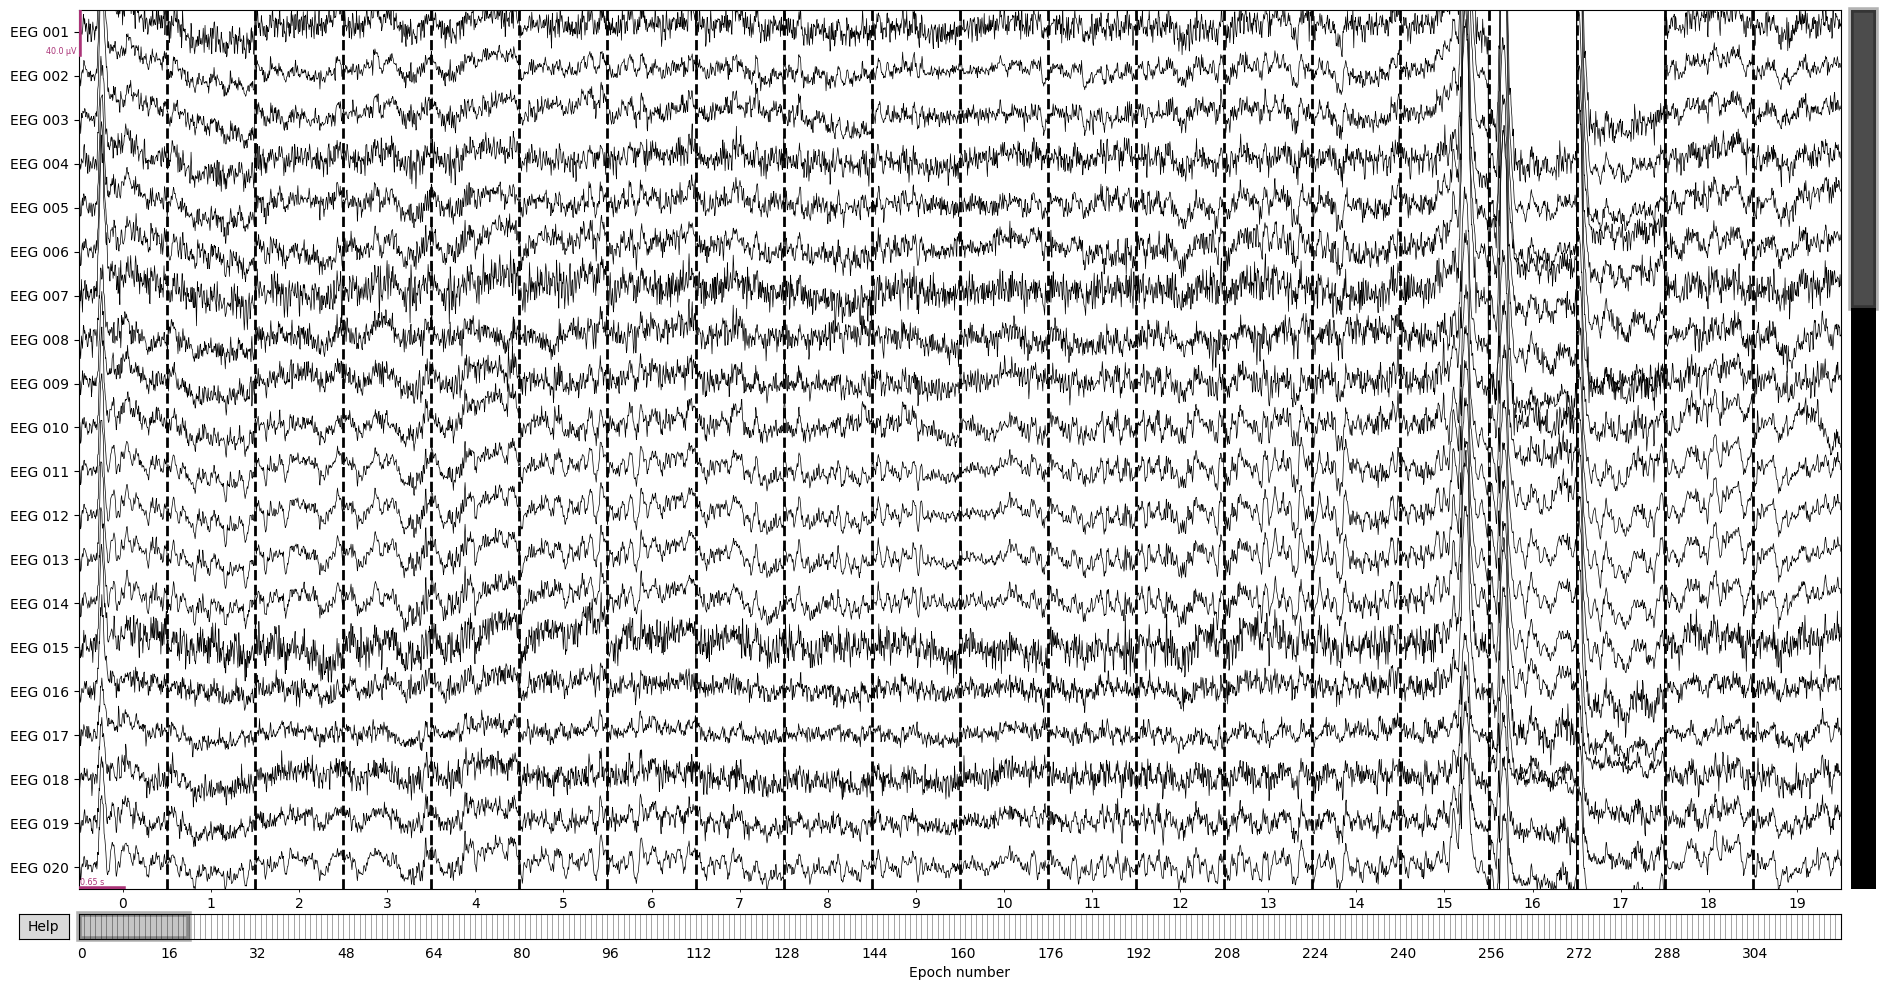

In [11]:
epochs = mne.epochs.Epochs(raw, events, event_id=event_id, tmin=-0.3, tmax=1)
epochs.plot();

**Example**: Looking at individual epochs, it is not possible to see the brain responses to individual events. To see the relatioshi between brain activity and events, we must average the epochs first. Run the cell below to `.average()` all `"visual"` epochs and `.plot()` the average.

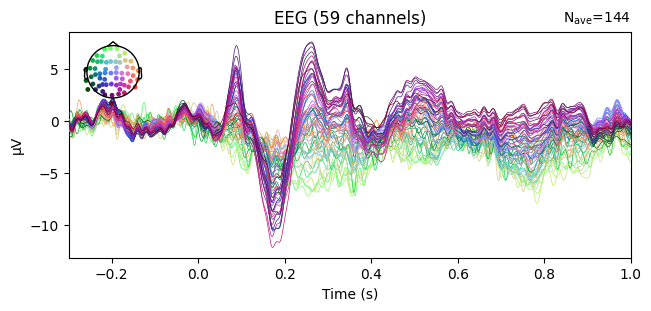

In [12]:
epochs["visual"].average().plot();

**Exercise**: Create epochs from `0.1` seconds before to `0.5` seconds after each event and plot the average of all `"visual"` epochs, again.

Not setting metadata
320 matching events found
Setting baseline interval to [-0.09989760657919393, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated


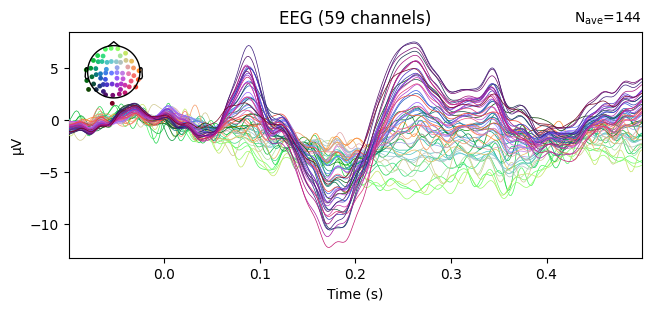

In [13]:
epochs = mne.epochs.Epochs(raw, events, event_id, tmin=-0.1, tmax=0.5)
epochs["visual"].average().plot();

**Exercise**: Plot the average brain response to all `"auditory"` events.

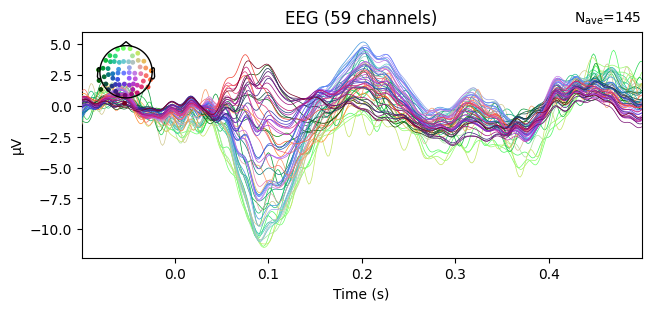

In [14]:
epochs["auditory"].average().plot();

**Exercise**: Plot the average brain response to all `"button"` events. Why is this average response more noisy than the previous ones?

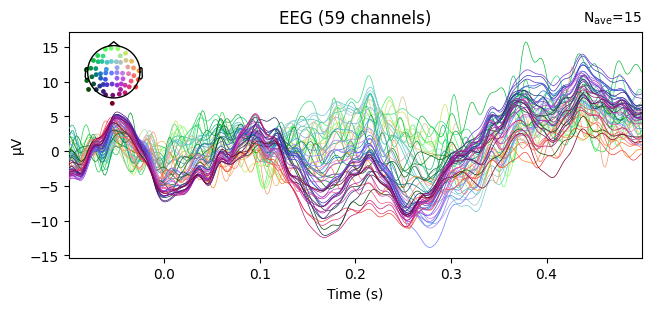

In [15]:
epochs["face"].average().plot();

**Exercise**: Create `epochs` from `0.1` seconds before to `2` seconds after each event and plot the average response to `"auditory"` events.

Not setting metadata
320 matching events found
Setting baseline interval to [-0.09989760657919393, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated


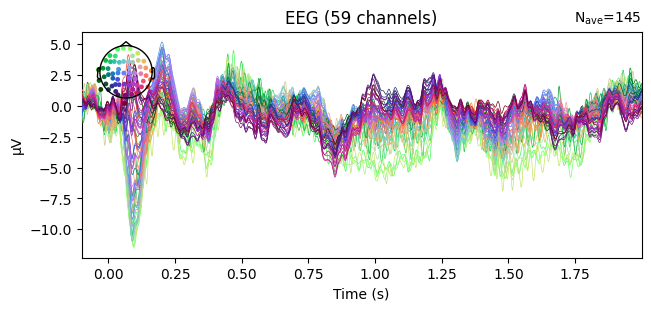

In [16]:
epochs = mne.epochs.Epochs(raw, events, event_id, tmin=-0.1, tmax=2)
epochs["auditory"].average().plot();

**Exercise**: Per default, MNE uses the interval before the event as a `baseline` period and subtracts it from the rest of the signal. Repeat the code from above but set `baseline=None` when compting the `epochs` to not apply any baseline correction. How does the average response differ from the previous exercise?

Not setting metadata
320 matching events found
No baseline correction applied
0 projection items activated


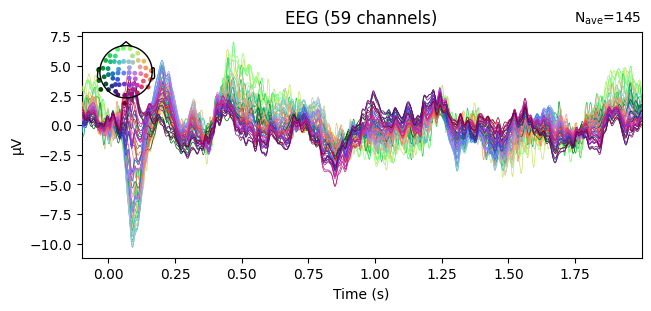

In [17]:
epochs = mne.epochs.Epochs(raw, events, event_id, tmin=-0.1, tmax=2, baseline=None)
epochs["auditory"].average().plot();

**Exercise**: Baseline correction can lead to spurious features because activity in the baseline period can be projected into the rest of the signal. To test what can happen when using an interval with event-related activity as baseline, set `baseline=0.05, 0.15` when computing the epochs. Then, plto the average response to all `"auditory"` events again.

Not setting metadata
320 matching events found
Applying baseline correction (mode: mean)
0 projection items activated


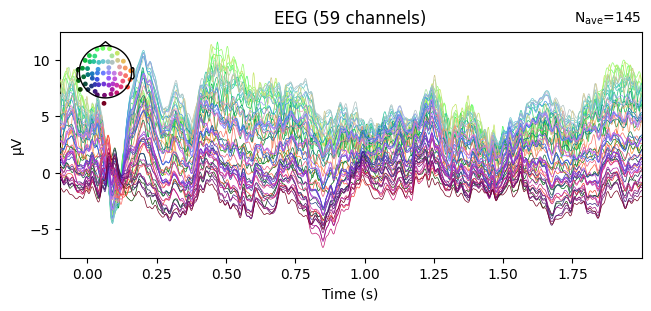

In [18]:
epochs = mne.epochs.Epochs(raw, events, event_id, tmin=-0.1, tmax=2, baseline=(0.05, 0.15))
epochs["auditory"].average().plot();

## Creating Topographical Plots and Referencing EEG

| Code | Description |
| --- | --- |
| `epochs.average().plot_joint()` | Plot the average of all `epochs` and create topographical plots at time points where the average peaks |
| `epochs["stim1"].average().plot_joint()` | Average all epochs for the `"stim1"` event ID and create a joint plot |
| `epochs.set_eeg_reference("average")` | Set the reference to the average of all channels |
| `epochs.set_eeg_reference(["EEG 001"])` | Set the reference to channel `"EEG 001"` |
| `epochs.set_eeg_reference(["EEG 001", "EEG 002"])` | Set the reference to the average of channels `"EEG 001"` and `"EEG 002"` |

Not setting metadata
320 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 320 events and 361 original time points ...
0 bad epochs dropped
No projector specified for this dataset. Please consider the method self.add_proj.


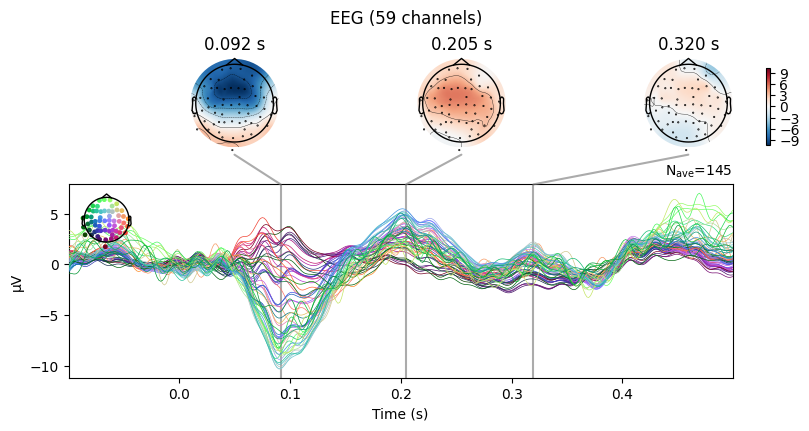

In [19]:
epochs = mne.epochs.Epochs(raw, events, event_id, tmin=-0.1, tmax=0.5, baseline=None, preload=True)
epochs["auditory"].average().plot_joint();

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
No projector specified for this dataset. Please consider the method self.add_proj.


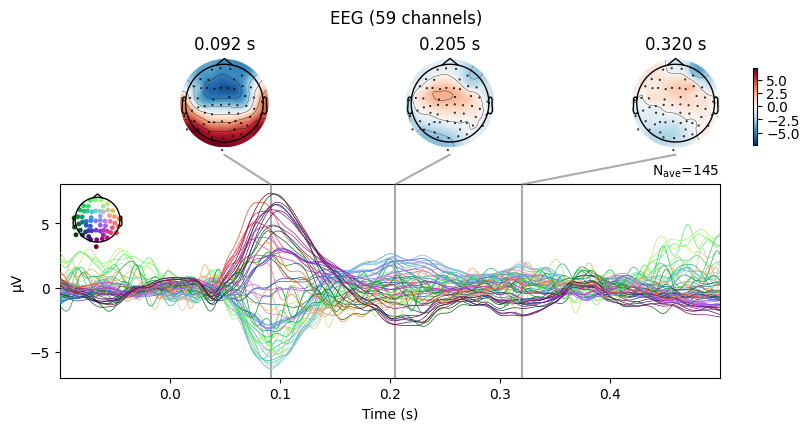

In [20]:
epochs.set_eeg_reference("average")
epochs["auditory"].average().plot_joint();

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
No projector specified for this dataset. Please consider the method self.add_proj.


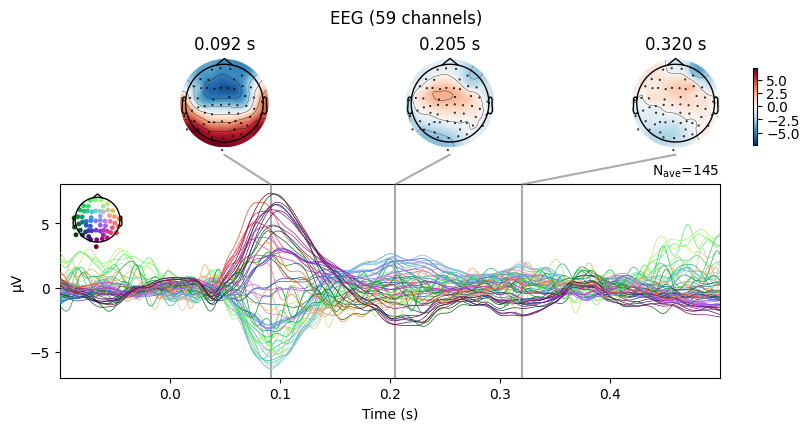

In [21]:
epochs.set_eeg_reference("average")
epochs["auditory"].average().plot_joint();

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
No projector specified for this dataset. Please consider the method self.add_proj.


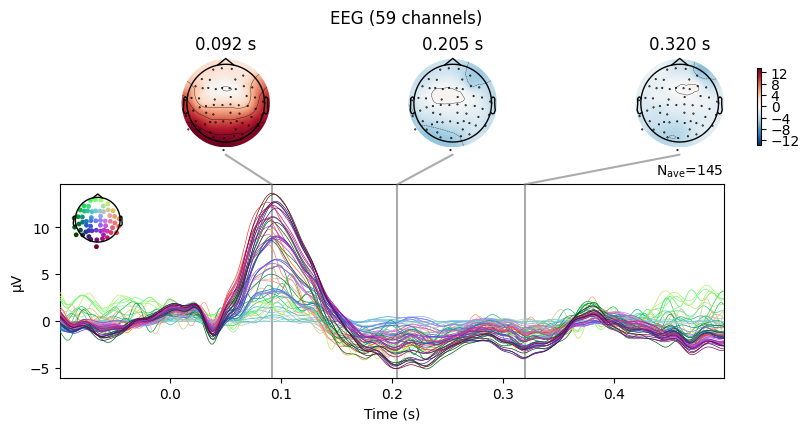

In [22]:
epochs.set_eeg_reference(["EEG 012"])
epochs["auditory"].average().plot_joint();

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
No projector specified for this dataset. Please consider the method self.add_proj.


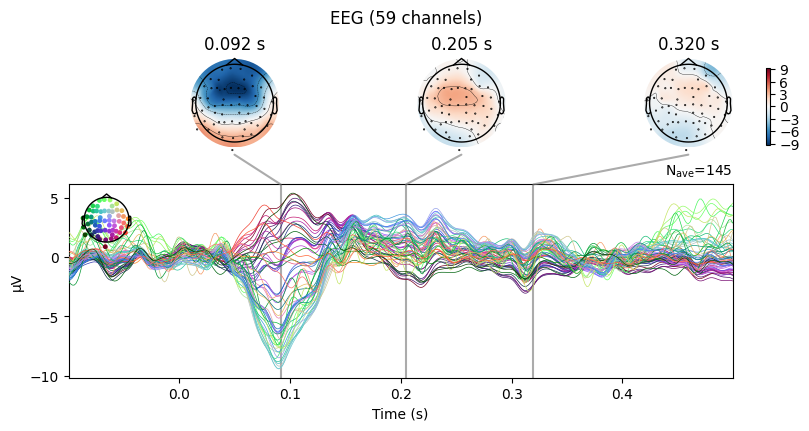

In [23]:
epochs.set_eeg_reference(["EEG 017", "EEG 024"])
epochs["auditory"].average().plot_joint();

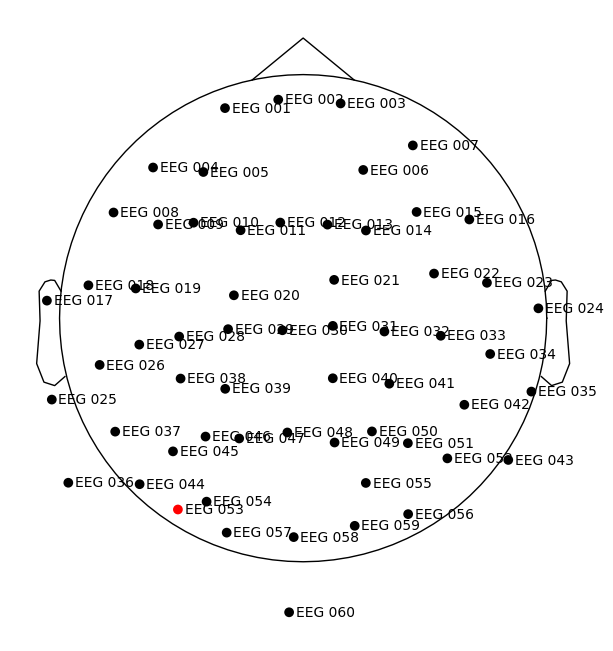

In [24]:
epochs.plot_sensors(show_names=True);

## Finding and Rejecting Bad Epochs

Run the cell below to create a new set of `epochs` from `-0.1` to `0.5` seconds and no `baseline` correction, referenced to the `"average"` of all channels.

In [25]:
epochs = mne.epochs.Epochs(raw, events, event_id, tmin=-0.1, tmax=0.5, preload=True, baseline=None)
epochs.set_eeg_reference("average");

Not setting metadata
320 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 320 events and 361 original time points ...
0 bad epochs dropped
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


**Example**: Plot all `"auditory"` epochs as an image. In the top panel, every row in the image represents a single epoch. The bottom panel shows the global field power GFP (i.e. the standard deviation across all channels) averaged across epochs.

Not setting metadata
145 matching events found
No baseline correction applied
0 projection items activated
combining channels using GFP (eeg channels)


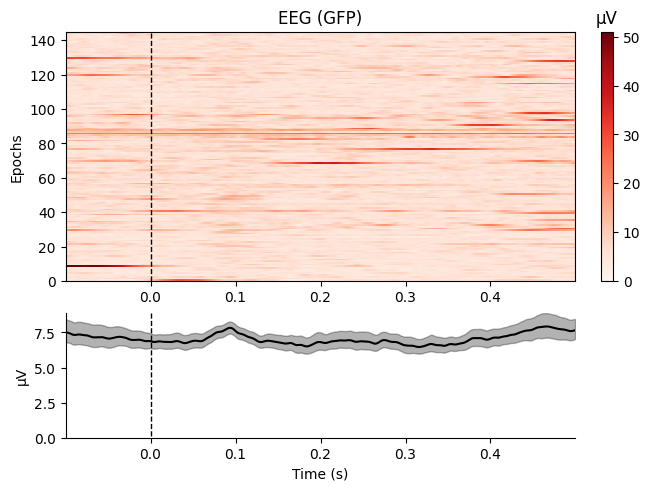

In [26]:
epochs["auditory"].plot_image();

**Example**: The image plot shows that there are a few epochs with very high response amplitudes. To remove these epochs, define a dictionary of `reject_criteria` to reject epochs with a peak amplitude above $100\mu V$ (i.e. `100e-6` $V$). Then, copy the `epochs`, apply the rejection criteria and plot the drop log.

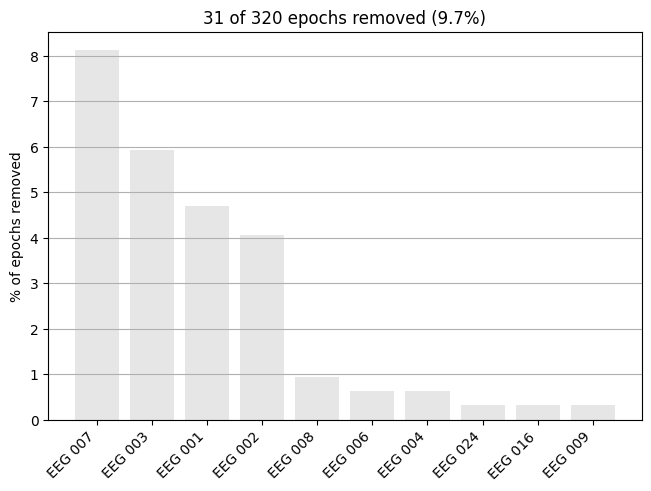

In [27]:
reject_criteria = {"eeg":100e-6}
epochs_clean=epochs.copy()
epochs_clean.drop_bad(reject=reject_criteria, verbose=False)
epochs_clean.plot_drop_log();

**Exercise**: Define a new dictionary of `reject_criteria` to reject epochs with a peak amplitude above $60\mu V$, apply it to a copy of `epochs` and plot the drop log. 

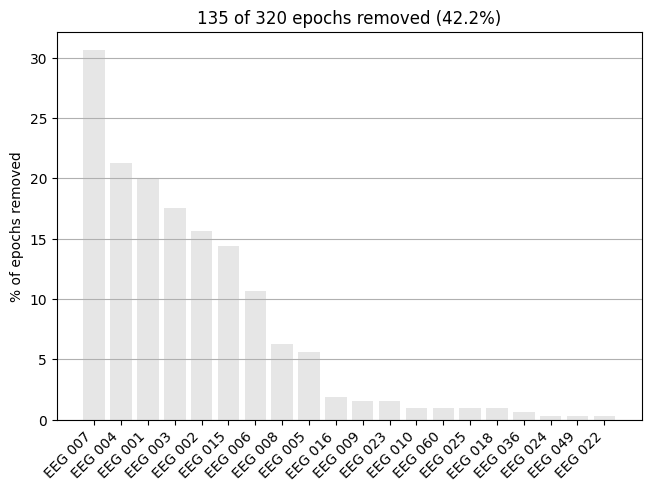

In [28]:
reject_criteria = {"eeg":60e-6}
epochs_clean=epochs.copy()
epochs_clean.drop_bad(reject=reject_criteria, verbose=False)
epochs_clean.plot_drop_log();

**Exercise**: Plot all `"auditory"` trials as an image using the cleaned epochs. You should see fewer outliers compared to the previous image plot.

Not setting metadata
86 matching events found
No baseline correction applied
0 projection items activated
combining channels using GFP (eeg channels)


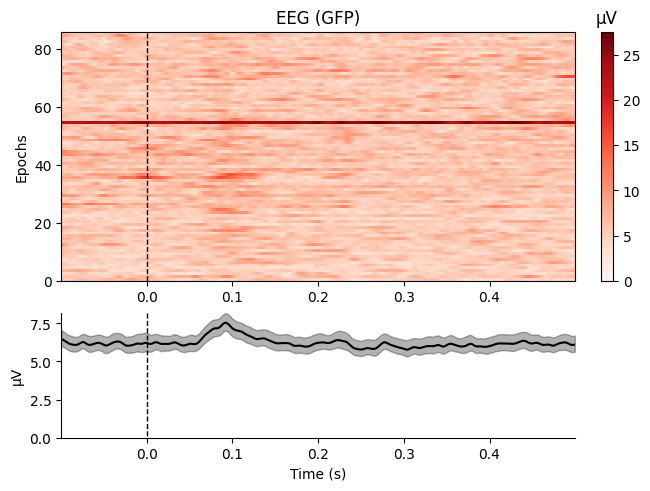

[<Figure size 640x480 with 3 Axes>]

In [29]:
epochs_clean["auditory"].plot_image()

**Exercise**: Define a new dictionary of `reject_criteria` to reject epochs with a peak amplitude above $80\mu V$, apply it to a copy of `epochs` and plot the drop log. 

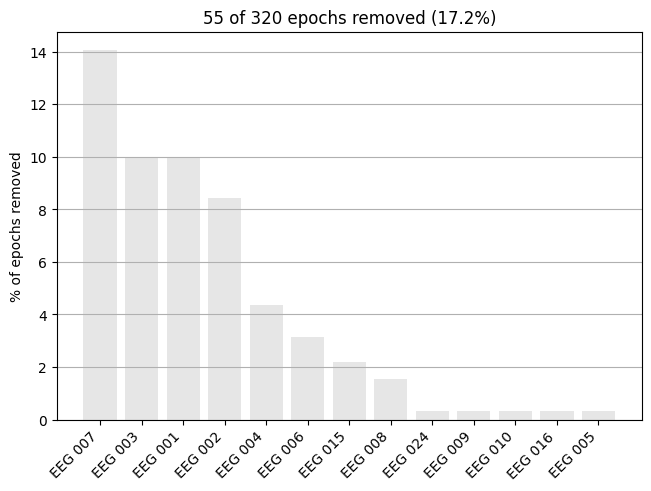

In [30]:
reject_criteria = {"eeg":80e-6}
epochs_clean=epochs.copy()
epochs_clean.drop_bad(reject=reject_criteria, verbose=False)
epochs_clean.plot_drop_log();

**Example**: It seems that a few channels appear more frequently in bad epochs. Add the channel `"EEG 007"` to the list of bad channels stored in `epochs.info["bads"]` and interpolate all bad channels. Then, apply the same rejection criteria again - after interpolation, we have to reject fewer epochs.

In [31]:
epochs.info["bads"].append("EEG 007")
epochs.interpolate_bads();

Setting channel interpolation method to {'eeg': 'spline'}.


Interpolating bad channels.
    Automatic origin fit: head of radius 91.2 mm
Computing interpolation matrix from 58 sensor positions
Interpolating 2 sensors


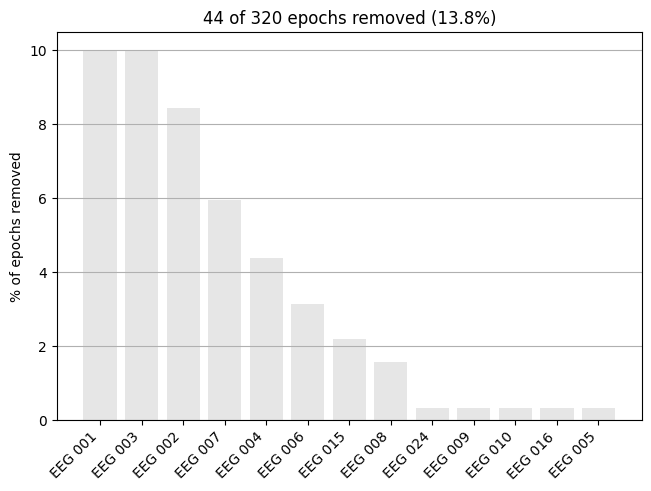

In [32]:
reject_criteria = {"eeg":80e-6}
epochs_clean=epochs.copy()
epochs_clean.drop_bad(reject=reject_criteria, verbose=False)
epochs_clean.plot_drop_log();

**Exercise**: Add channel `"EEG 001"` and `"EEG 003"` to the list of bad channels and interplolate them. Then, apply the rejection criteria again. Did interpolating those sensors change the number of rejected epochs?

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 91.2 mm
Computing interpolation matrix from 58 sensor positions
Interpolating 2 sensors


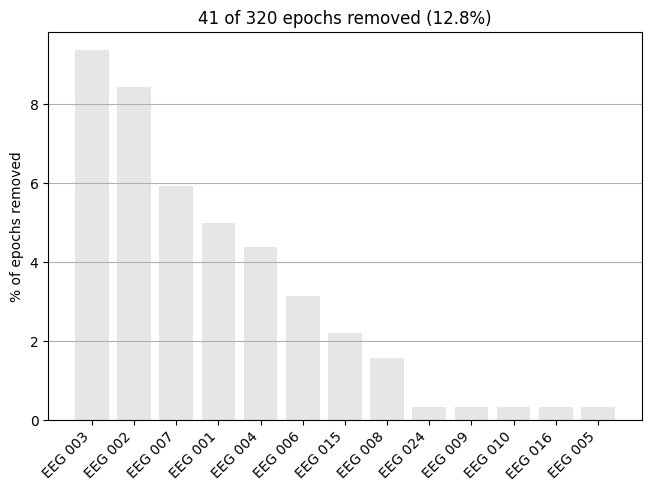

In [33]:
epochs.info["bads"].append("EEG 001")
epochs.info["bads"].append("EEG 003")
epochs.interpolate_bads();
reject_criteria = {"eeg":80e-6}
epochs_clean=epochs.copy()
epochs_clean.drop_bad(reject=reject_criteria, verbose=False)
epochs_clean.plot_drop_log();

**Exercise**: Plot all `"auditory"` from the cleaned epochs again to confirm that the rejection criteria removed the outliers.

Not setting metadata
124 matching events found
No baseline correction applied
0 projection items activated
combining channels using GFP (eeg channels)


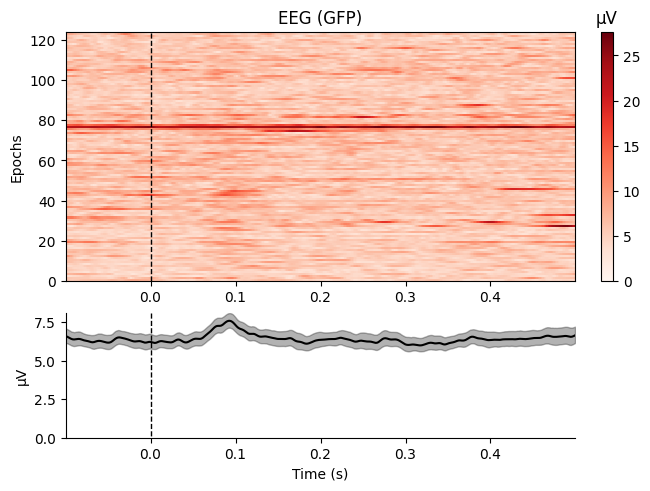

In [34]:
epochs_clean["auditory"].plot_image();

## Demo: Automated Rejection of Bad Epochs

In [35]:
from autoreject import AutoReject

ar = AutoReject()
epochs_clean, reject_log = ar.fit_transform(epochs["auditory"], return_log=True)

Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/60 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/60 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/145 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

...

  0%|          | Repairing epochs : 0/145 [00:00<?,       ?it/s]

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.60 and n_interpolate=32


  0%|          | Repairing epochs : 0/145 [00:00<?,       ?it/s]

Dropped 21 epochs: 8, 29, 30, 32, 40, 68, 69, 76, 88, 90, 93, 94, 95, 96, 97, 103, 114, 118, 119, 127, 129


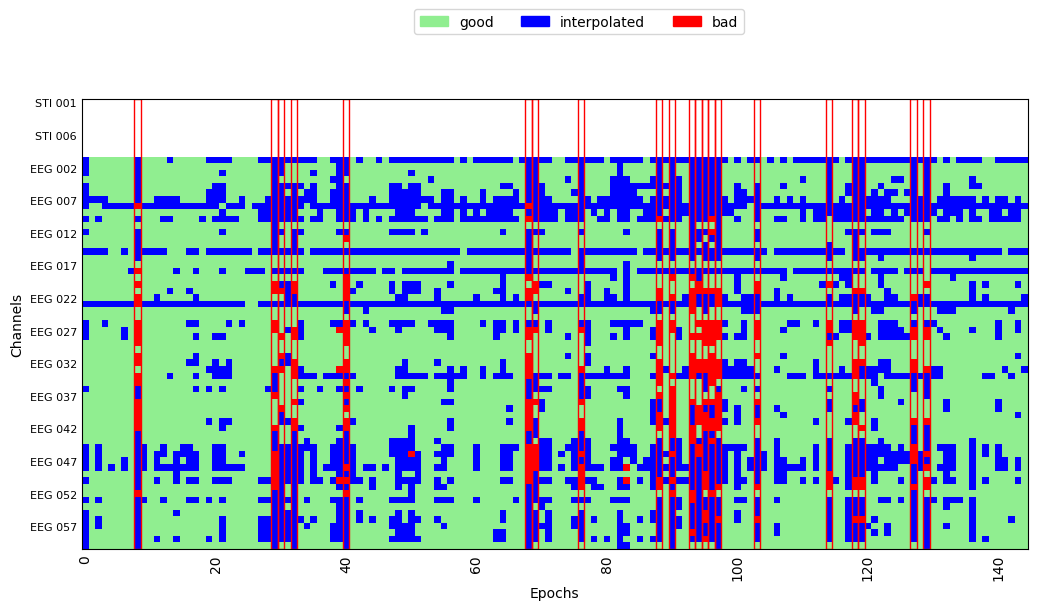

In [41]:
reject_log.plot(orientation='horizontal');

In [45]:
reject_log.__dict__.keys()

dict_keys(['bad_epochs', 'labels', 'ch_names'])

In [47]:
ar.__dict__.keys()
ar.threshes_


{'EEG 001': np.float64(3.0470150016757322e-05),
 'EEG 002': np.float64(6.613971745648932e-05),
 'EEG 003': np.float64(6.345946251745912e-05),
 'EEG 004': np.float64(6.0769579956353626e-05),
 'EEG 005': np.float64(3.720926295889844e-05),
 'EEG 006': np.float64(3.916406045093104e-05),
 'EEG 007': np.float64(3.1430461582544446e-05),
 'EEG 008': np.float64(3.156969287532501e-05),
 'EEG 009': np.float64(3.785168484723463e-05),
 'EEG 010': np.float64(2.9573104682788662e-05),
 'EEG 011': np.float64(4.6199102292507583e-05),
 'EEG 012': np.float64(3.2237676915970444e-05),
 'EEG 013': np.float64(3.989103612795879e-05),
 'EEG 014': np.float64(4.355571748816927e-05),
 'EEG 015': np.float64(3.86420925294215e-05),
 'EEG 016': np.float64(4.786195699590422e-05),
 'EEG 017': np.float64(3.709609591696161e-05),
 'EEG 018': np.float64(3.3298653347823954e-05),
 'EEG 019': np.float64(3.188925524794189e-05),
 'EEG 020': np.float64(2.126338477345074e-05),
 'EEG 021': np.float64(2.314050673911961e-05),
 'EEG 0

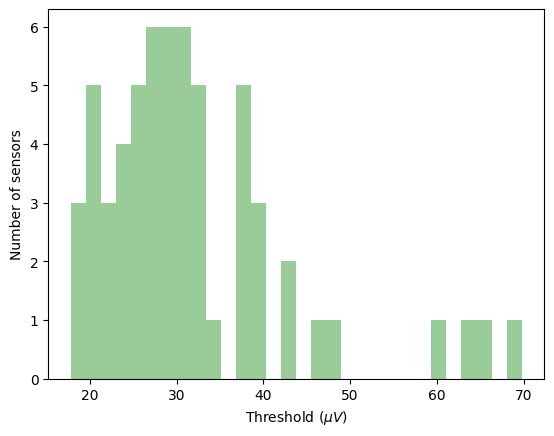

In [50]:
plt.hist(1e6 * np.array(list(ar.threshes_.values())), 30,
         color='g', alpha=0.4)
plt.xlabel('Threshold ($\mu V$)')
plt.ylabel('Number of sensors')
plt.show()